# Segmentación de clientes con K-Means

En este documento puedes desarrollar el eunciado adjunto (contiene algunas pistas y preguntas adicionales)

## Objetivos
- Comprender qué es clustering.
- Aplicar K-Means.
- Elegir el número óptimo de clusters.
- Interpretar los resultados.

## Pregunta Inicial
**¿Podemos identificar tipos de clientes según su comportamiento?**

## Descripción de las columnas
- **CustomerID**: Identificador único de cada cliente. No es relevante para el clustering, ya que no aporta información útil para la segmentación.
- **Genre**: Género del cliente (Male/Female). En algunos casos puede ser útil si se convierte a valores numéricos, aunque K-Means trabaja mejor con variables numéricas continuas.
- **Age**: Edad del cliente. Puede ser un factor clave en la segmentación, ya que distintos grupos de edad pueden tener diferentes patrones de gasto.
- **Annual Income (k$)**: Ingreso anual del cliente en miles de dólares. Es un indicador relevante para clasificar clientes en función de su poder adquisitivo.
- **Spending Score (1-100)**: Puntuación asignada a cada cliente según sus hábitos de gasto y comportamiento de compra (por ejemplo, un puntaje alto puede indicar que el cliente gasta mucho en relación con su ingreso).

## 1. Carga de datos

In [35]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ClientesCentroComercial.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Exploración inicial

In [36]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [37]:

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Cuestiones
1. ¿Qué variables te parecen más útiles para agrupar clientes?
    - Principalmente me parecen utiles las variables referentes a los ingresos porque nos permiten ver los clientes que nos interesa mantener y los que nos puede interesar hacer que gasten más, luego la edad quizás nos ayude en saber que tipos de productos compran en base a cada edad por ejemplo.
2. ¿Hay alguna variable que no tenga sentido usar?
    - El customerID porque es una variable única que no nos aporta ninguna información.

## 3. Selección de variables

Vamos a trabajar con dos variables especialmente útiles para segmentar clientes:
- **Annual Income (k$)**
- **Spending Score (1-100)**

In [38]:

X = df[["Annual Income (k$)", "Spending Score (1-100)", "Age"]]
X.head()

,Annual Income (k$),Spending Score (1-100),Age
0,15,39,19
1,15,81,21
2,16,6,20
3,16,77,23
4,17,40,31


**Recuerda:** estamos usando variables relacionadas con capacidad económica y comportamiento de compra.

## 4. Visualización inicial

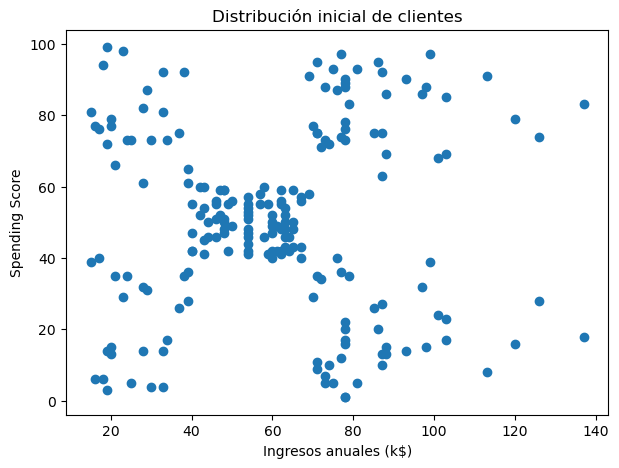

In [39]:

plt.figure(figsize=(7,5))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1])
plt.xlabel("Ingresos anuales (k$)")
plt.ylabel("Spending Score")
plt.title("Distribución inicial de clientes")
plt.show()

## Cuestión
**¿Observas posibles grupos de clientes a simple vista?**
    - A simple vista podemos ver que en la zona del 60/60 hay una concentración masiva de puntos que seguramente represente al grupo mas promedio. arriba a la derecha también puedo ver otro grupo por la concentración de puntos, de gente que gasta mucho y tiene grandes ingresos.

## 5. Escalado de datos

**Importante:** K-Means utiliza distancias.  
Por eso, antes de aplicar el algoritmo, conviene poner las variables en la misma escala.

In [40]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# COMPLETAR
X_scaled = scaler.fit_transform(X)

## 6. Método del codo

Ahora vamos a probar distintos valores de **K** para decidir cuántos clusters conviene usar.

In [41]:

from sklearn.cluster import KMeans

inercia = []

for k in range(1, 11):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)

    # COMPLETAR
    modelo.fit(X_scaled)

    inercia.append(modelo.inertia_)

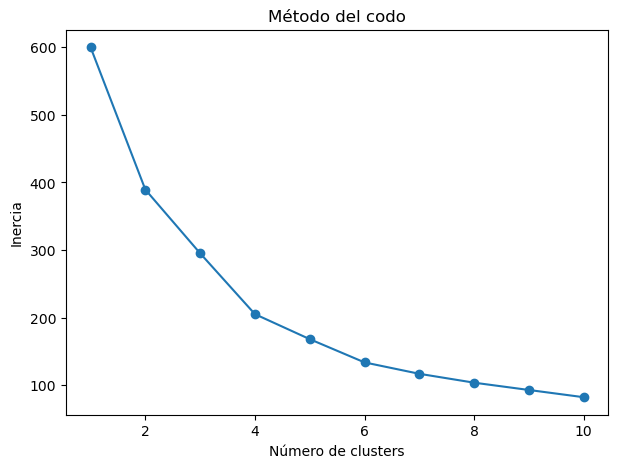

In [42]:

plt.figure(figsize=(7,5))
plt.plot(range(1, 11), inercia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

## Cuestiones
1. ¿En qué valor de **K** parece producirse el “codo”?
    - El valor de k en el que se produce el codo es en el 5 debido a que a partir de ese punto el valor de la inercia se reduce muy poco, por lo que podemos interpretar que este punto es el más óptimo
2. ¿Por qué ese punto puede considerarse un buen compromiso?
    - Además de por lo anteriormente dicho, si nos fijamos en la gráfica anterior, quizás podemos distinguir 5 tipos de grupos debido a la agrupación de los puntos por lo que me parece un valor mas que coherente.

## 7. Aplicación de K-Means

In [43]:

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# COMPLETAR
clusters = kmeans.fit_predict(X_scaled)

## 8. Visualización de clusters

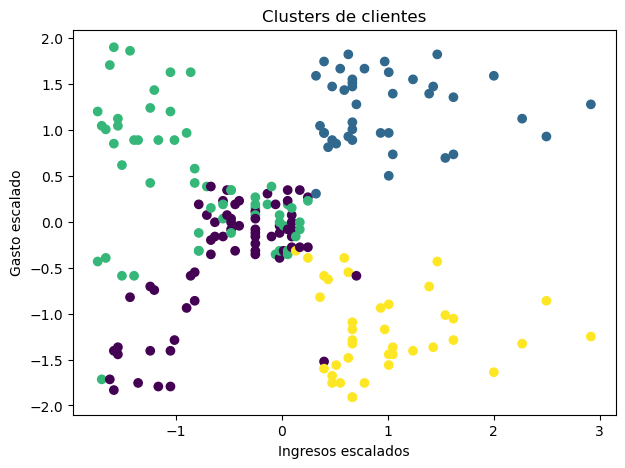

In [44]:

plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.xlabel("Ingresos escalados")
plt.ylabel("Gasto escalado")
plt.title("Clusters de clientes")
plt.show()

## 9. Centroides

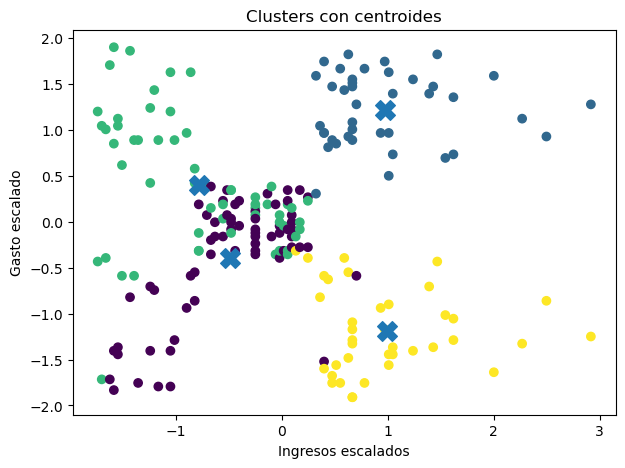

In [45]:

centroides = kmeans.cluster_centers_

plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(centroides[:, 0], centroides[:, 1], marker="X", s=200)
plt.xlabel("Ingresos escalados")
plt.ylabel("Gasto escalado")
plt.title("Clusters con centroides")
plt.show()

## 10. Interpretación de resultados

Añade una nueva columna al DataFrame con el cluster asignado a cada cliente.

In [46]:

# COMPLETAR
df["cluster"] = clusters
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [ ]:
df.groupby("cluster")[["Annual Income (k$)", "Spending Score (1-100)", "Age"]].mean()

,Annual Income (k$),Spending Score (1-100),Age
cluster,,,
0,47.707692,39.969231,53.984615
1,86.100000,81.525000,32.875000
2,40.000000,60.298246,25.438596
3,86.500000,19.578947,39.368421


## Cuestiones
1. ¿Qué tipo de clientes representa cada cluster?
    - El cluster numero 0, representa el grupo más promedio, gente que tiene una puntuación de gasto y unos ingresos anuales promedios, por lo que nos puede interesar ver que les mantiene comprando y buscar como hacer que compren más. (clientes promedio)
    - El cluster numero 1, es el cluster de la gente con más ingresos y que mas gasta, por lo que nos puede interesar ver que hace que gasten tanto y tratar de mantenerlos. (clientes vip)
    - El cluster numero 2, es el que muestra la gente con pocos ingresos pero con gran puntuación de gasto en el centro, por lo que nos puede interesar ver que compran para saber quizás cuales son los productos más asequibles que mas se compran para tratar de atraer a gastar a otros grupos (clientes fidelizados)
    - El cuarto cluster nos muestra a los clientes que tienen muchos ingresos pero que gastan poco en el centro, clientes que sabemos que tienen pasta y nos interesa que gasten más, por lo que haciendo un estudio de los 2 grupos anteriores, podriamos tratar de hacer que compren más productos que se adapten a sus necesidades o hacerles ofertas para fidelizarlos (clientes con presupuesto sin fidelizar)
    - El quinto cluster muestra a los clientes con pocos ingresos y poco gasto en el centro, por lo que nos interesa saber que productos más asequibles ofrecerles y asegurar que compren más(clientes con menos presupuesto sin fidelizar)
2. ¿Cuál te parece más interesante para el negocio?
    - El cluster más interesante es el de gente con pasta y que gasta poco, ya que son aquellos que mas pasta nos pueden aportar y más nos interesa fidelizar y hacer que compren más 
3. ¿Qué estrategia comercial podría aplicarse a cada grupo? Dicho en la 1
4. ¿Qué pasaría si no hubiéramos escalado los datos?
    - Que a la hora de ejecutar kmeans, el modelo necesitaria mucha más potencia, ya que la dispersión de los datos es mucho mayor y encima eso podria alterarnos el resultado
5. ¿K-Means siempre encuentra los mejores grupos?
    - No, ya que primero no sabemos cual es el mejor numero de grupos ya que el k lo introducimos de forma manual, además de que si el problema tuviese una densidad gráfica diferente, kmeans sería muy ineficiente ya que solo se adapta bien a figuras geometricas simples como esferas, y también porque la inicialización de los centroides se hace de forma aleatorio, por lo que la misma ejecución podría darnos resultados diferentes en cada ejecución que hagamos
6. ¿Qué limitaciones tiene este algoritmo?
    - El no saber que numero de clusters es el más óptimo, el que solo se adapta a densidades esfericas por lo que si tenemos un problema que necesita otras densidades podría dar problemas y que la inicialización de los centroides es aleatoria por lo que no asegura que encuentre los mejores grupos posibles

## 11. Opcional

Prueba a repetir el análisis añadiendo la variable **Age**.

Preguntas:
- ¿Cambian los clusters?
    - Los clusters cambian bastante, ahora el numero más óptimo es el 4, en base al metodo del codo, y hace que los grupos se entremezclen un poco.
- ¿Son más realistas o más difíciles de interpretar?
    - Son bastante mas dificiles de interpretar debido a que hay 2 clusters que tienen datos mezclados lo que nos complica distinguir esos 2 grupos en su totalidad